In [1]:
import tensorflow as tf

cifar10 = tf.keras.datasets.cifar10

(x_train, y_train), (x_test_val, y_test_val) = cifar10.load_data()
print("x_train.shape: ", x_train.shape)
print("y_train.shape: ", y_train.shape)
print("x_test_val.shape: ", x_test_val.shape)
print("y_test_val.shape: ", y_test_val.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3484s 20us/step
x_train.shape:  (50000, 32, 32, 3)
y_train.shape:  (50000, 1)
x_test_val.shape:  (10000, 32, 32, 3)
y_test_val.shape:  (10000, 1)


In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

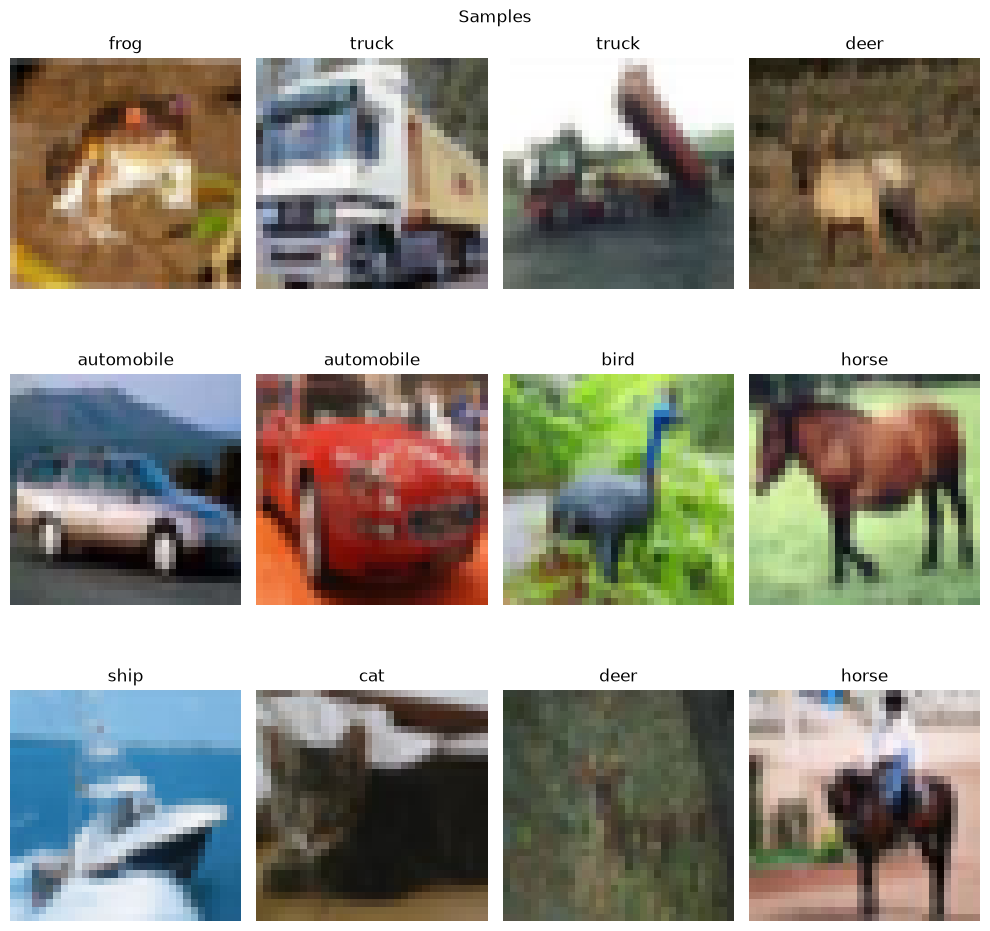

In [3]:
import matplotlib.pyplot as plt

def show_samples(data, labels):
    fig, axes = plt.subplots(3, 4, figsize=(10, 10))

    axes = axes.flatten()

    for i in range(len(axes)):
        
        axes[i].imshow(data[i])
        
        class_index=labels[i][0]
        
        class_name=class_names[class_index]
        axes[i].set_title(class_name)
        
        axes[i].axis('off')  
    
    
    plt.tight_layout()
    
    fig.suptitle("Samples")
    
    plt.show()

show_samples(x_train, y_train)

In [4]:
from sklearn.model_selection import train_test_split

x_test, x_val, y_test, y_val = train_test_split(x_test_val, y_test_val, test_size=0.5)

In [5]:
x_train = x_train/255.0
x_test = x_test/255.0
x_val = x_val/255.0

In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'  ))

model.add(Conv2D(32, (3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu' ))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train, batch_size=128, epochs=40, validation_data=(x_val, y_val))

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.3948 - loss: 1.6427 - val_accuracy: 0.5476 - val_loss: 1.2604
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5542 - loss: 1.2445 - val_accuracy: 0.6138 - val_loss: 1.0698
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6160 - loss: 1.0862 - val_accuracy: 0.6652 - val_loss: 0.9333
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6577 - loss: 0.9715 - val_accuracy: 0.6976 - val_loss: 0.8645
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6832 - loss: 0.8955 - val_accuracy: 0.7176 - val_loss: 0.8201
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7075 - loss: 0.8332 - val_accuracy: 0.7244 - val_loss: 0.7859
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7257 - loss: 0.7862 - val_accuracy: 0.7406 - val_loss: 0.7616
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7371 - loss: 0.7463 - 

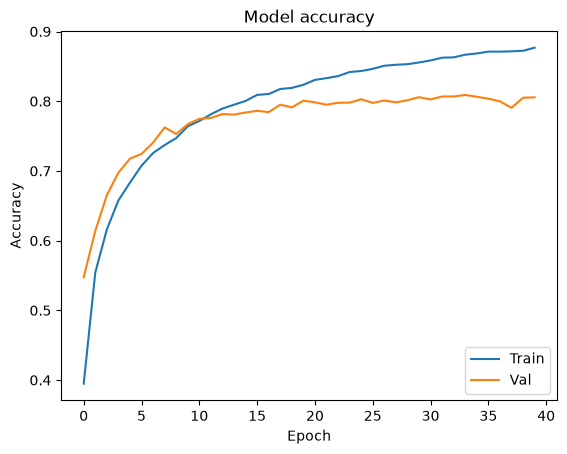

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [9]:
loss, accuracy = model.evaluate(x_test, y_test)
print('Accuracy on test set:', accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8006 - loss: 0.6224
Accuracy on test set: 0.800599992275238


In [26]:
!pip install scikeras

In [28]:

from sklearn.model_selection import GridSearchCV

from scikeras.wrappers import KerasClassifier

import pandas as pd
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

def create_model(filters=32,
                 kernel_size=(3, 3), 
                 pool_size=(2, 2),
                 activation='relu', 
                 optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 dropout_rate=0.25,
                 dense_units=512,
                 dense_dropout_rate=0.5):
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    model.add(Conv2D(filters=filters, kernel_size=kernel_size, activation=activation))
    model.add(Conv2D(filters=filters, kernel_size=kernel_size, activation=activation))
    model.add(MaxPooling2D(pool_size=pool_size))
    model.add(Dropout(dropout_rate))
    model.add(Conv2D(filters=2*filters, kernel_size=kernel_size, activation=activation))
    model.add(Conv2D(filters=2*filters, kernel_size=kernel_size, activation=activation))
    model.add(MaxPooling2D(pool_size=pool_size))
    model.add(Dropout(dropout_rate))
    model.add(Flatten())
    model.add(Dense(units=dense_units, activation=activation))
    model.add(Dropout(dense_dropout_rate))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
    return model


model_class_keras = KerasClassifier(model=create_model, verbose=0)

param_grid = {
    'model__filters': [32, 64],
    'model__kernel_size': [(3, 3),(4,4) ],
    'model__pool_size': [(2, 2), (4,4)],
    'model__activation': ['relu'],
    'model__optimizer': ['adam'],
    'model__loss': ['sparse_categorical_crossentropy'],
    'model__dropout_rate': [0.2, 0.25],
    'model__dense_units': [256, 512],
    'model__dense_dropout_rate': [0.4, 0.5]
}

cv =5

grid = GridSearchCV(estimator=model_class_keras, param_grid=param_grid, cv=cv, verbose=0)

grid_result = grid.fit(x_train, y_train)

results_df = pd.DataFrame(grid_result.cv_results_)

results_df.to_csv('grid_search_results.csv', index=False)


KeyboardInterrupt: 

In [ ]:
grid_result.best_params_

In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'  ))

model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation='relu' ))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dropout(0.4))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=128, epochs=40, validation_data=(x_val, y_val))

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.4076 - loss: 1.6167 - val_accuracy: 0.5546 - val_loss: 1.2332
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.5810 - loss: 1.1830 - val_accuracy: 0.6546 - val_loss: 0.9751
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.6616 - loss: 0.9589 - val_accuracy: 0.7148 - val_loss: 0.8294
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.7060 - loss: 0.8369 - val_accuracy: 0.7314 - val_loss: 0.7638
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.7365 - loss: 0.7489 - val_accuracy: 0.7478 - val_loss: 0.7210
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.7596 - loss: 0.6828 - val_accuracy: 0.7684 - val_loss: 0.6684
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.7765 - loss: 0.6294 - val_accuracy: 0.7856 - val_loss: 0.6369
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.7949 - loss: 0.5865 - 

In [14]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

print("Train Accuracy:", train_accuracy[-1])
print("Validation Accuracy:", val_accuracy[-1])

Train Accuracy: 0.9391199946403503
Validation Accuracy: 0.8051999807357788


In [15]:
model.save('cifar10_trained_model.keras')

In [16]:
from keras.models import load_model

model = load_model('cifar10_trained_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


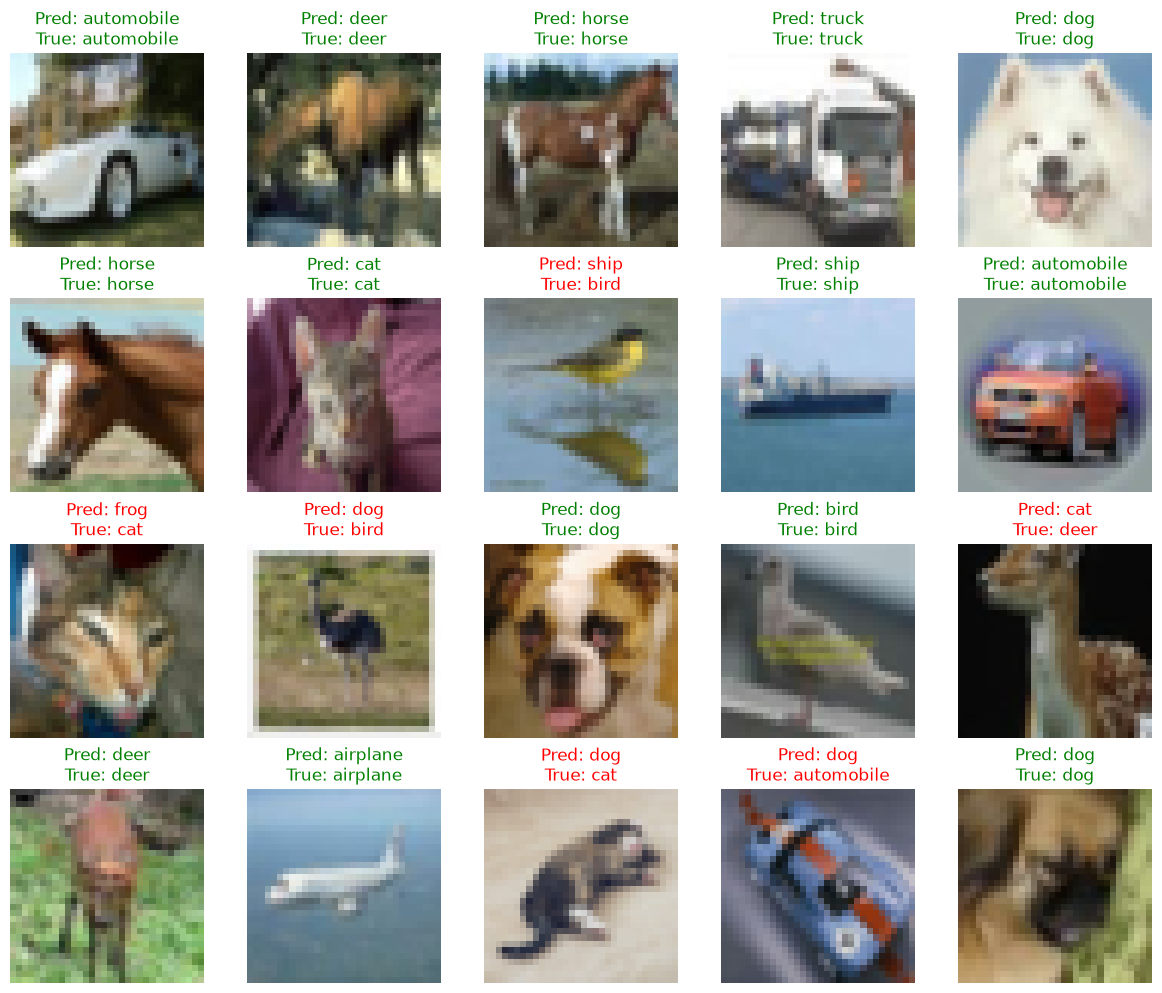

In [17]:
import matplotlib.pyplot as plt
import numpy as np

num_images = 20
x_test_selected = x_test[:num_images]
y_test_selected = y_test[:num_images]

predictions = model.predict(x_test_selected)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(num_images):
    
    axes[i].imshow(x_test_selected[i])
    axes[i].axis('off')
    
    predicted_label = class_names[predicted_labels[i]]
    true_label = class_names[y_test_selected[i][0]]
    
    if predicted_label == true_label:
        title_color = 'green'
    else:
        title_color = 'red'
    
    axes[i].set_title(f'Pred: {predicted_label}\nTrue: {true_label}', color=title_color)

plt.tight_layout()
plt.show()

In [18]:
for i in range(10):
    image = x_test[i]
    label = class_names[y_test[i][0]]
    
    file_name = f'image_{i}_label_{label}.png'
    plt.imsave(file_name, image)

In [19]:
image_path = 'image_5_label_bird.png'

In [20]:
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

image = load_img(image_path, target_size=(32, 32))

image_array = img_to_array(image)

image_array = np.expand_dims(image_array, axis=0)

image_array = image_array / 255.0

In [21]:
image_array.shape

(1, 32, 32, 3)

In [22]:
predictions = model.predict([image_array])
# print(predictions[0])

predicted_class = np.argmax(predictions[0])

predicted_label = class_names[predicted_class]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\01_Local_Jupyter_Notebooks\03_Deep_Learning\churn_env\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=('Tensor(shape=(1, 32, 32, 3))',)
  warnings.warn(msg)


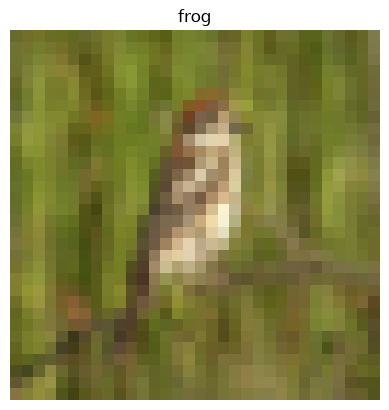

In [23]:
plt.imshow(image)
plt.title(predicted_label)
plt.axis('off')
plt.show()